In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
import pymongo
from dotenv import load_dotenv

### Connecting to MongoDb

In [2]:
# Define the absolute path to your .env file
env_path = r"C:\Users\Harshith N\Documents\Personal_projects\Customer-segmentation-MLOps-Pipeline\credentials\mongodb.env"

# Load the variables from the specific path
load_dotenv(dotenv_path=env_path)

# Access the variables using os.getenv
CONNECTION_URL = os.getenv("CONNECTION_URL")
DB_NAME = os.getenv("DB_NAME")
COLLECTION_NAME = os.getenv("COLLECTION_NAME")

# Initialize the client
client = pymongo.MongoClient(CONNECTION_URL)
data_base = client[DB_NAME]
collection = data_base[COLLECTION_NAME]

# Verification (Optional)
print(f"Connected to database: {data_base.name}")

Connected to database: Customer-segmentation


In [3]:
df = pd.DataFrame(list(collection.find()))
df.head()

,_id,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,69f4434b7db68afaf35cb1bc,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,69f4434b7db68afaf35cb1bd,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,69f4434b7db68afaf35cb1be,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,69f4434b7db68afaf35cb1bf,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,69f4434b7db68afaf35cb1c0,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               5000 non-null   object 
 1   order_id          5000 non-null   int64  
 2   order_date        5000 non-null   str    
 3   customer_id       5000 non-null   int64  
 4   product_category  5000 non-null   str    
 5   region            5000 non-null   str    
 6   quantity          5000 non-null   int64  
 7   unit_price        5000 non-null   float64
 8   discount          5000 non-null   float64
 9   payment_method    5000 non-null   str    
 10  delivery_days     5000 non-null   int64  
 11  customer_rating   5000 non-null   float64
 12  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(1), str(4)
memory usage: 507.9+ KB


In [6]:
df.describe().round(1)

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,12500.5,1505.7,4.0,308.4,0.2,6.1,3.0,1022.0
std,1443.5,290.8,2.0,169.3,0.1,3.2,1.2,825.6
min,10001.0,1000.0,1.0,15.2,0.0,1.0,1.0,11.2
25%,11250.8,1253.0,2.0,161.9,0.1,3.0,2.0,354.5
50%,12500.5,1510.0,4.0,309.9,0.2,6.0,3.0,796.6
75%,13750.2,1761.0,6.0,455.6,0.3,9.0,4.0,1515.7
max,15000.0,1999.0,7.0,600.0,0.4,11.0,5.0,4119.3


### Column Classification

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['order_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'revenue']
Categorical: ['_id', 'order_date', 'product_category', 'region', 'payment_method']


### Missing Value Analysis

In [8]:
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
}).sort_values(by="missing_pct", ascending=False)

print(missing_df)

                  missing_count  missing_pct
_id                           0          0.0
order_id                      0          0.0
order_date                    0          0.0
customer_id                   0          0.0
product_category              0          0.0
region                        0          0.0
quantity                      0          0.0
unit_price                    0          0.0
discount                      0          0.0
payment_method                0          0.0
delivery_days                 0          0.0
customer_rating               0          0.0
revenue                       0          0.0


### Duplicate Check

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Column-wise Validation

order_id
- Must be unique
- Should be integer-like

In [10]:
assert df['order_id'].is_unique, "order_id is not unique"
df['order_id'] = df['order_id'].astype(str)

order_date
- Should be valid datetime
- No future dates

In [11]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Check invalid dates
print(df['order_date'].isnull().sum())

# Feature engineering
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['dayofweek'] = df['order_date'].dt.day_name()

0


customer_id

- Should be categorical (not numeric measure)
- Check cardinality

In [12]:
df['customer_id'] = df['customer_id'].astype(str)
print(df['customer_id'].nunique())

989


product_category

- Limited known categories

In [13]:
print(df['product_category'].value_counts())

df['product_category'] = df['product_category'].str.strip().str.title()

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64


region


- Should belong to known regions

In [14]:
valid_regions = ['North', 'South', 'East', 'West']
invalid_regions = df[~df['region'].isin(valid_regions)]

print("Invalid regions:", invalid_regions.shape[0])

Invalid regions: 0


quantity

- Must be positive
- No unrealistic high values

In [15]:
print(df['quantity'].describe())

df = df[df['quantity'] > 0]


count    5000.000000
mean        4.044800
std         2.020398
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         7.000000
Name: quantity, dtype: float64


unit_price

- Must be > 0

In [16]:
df = df[df['unit_price'] > 0]


discount

- Range should be [0,1]

In [17]:
df = df[(df['discount'] >= 0) & (df['discount'] <= 1)]

payment_method

- Clean categories

In [18]:
df['payment_method'] = df['payment_method'].str.strip().str.title()
print(df['payment_method'].value_counts())

payment_method
Card      2270
Cod       1774
Wallet     956
Name: count, dtype: int64


customer_rating

- Range: 1–5

In [19]:
df = df[(df['customer_rating'] >= 1) & (df['customer_rating'] <= 5)]

revenue

- Should match formula: quantity * unit_price * (1 - discount)

In [20]:
df['expected_revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])

# Check mismatch
df['revenue_diff'] = df['revenue'] - df['expected_revenue']
print(df['revenue_diff'].abs().mean())

0.0023868400000010516


### Distribution Analysis

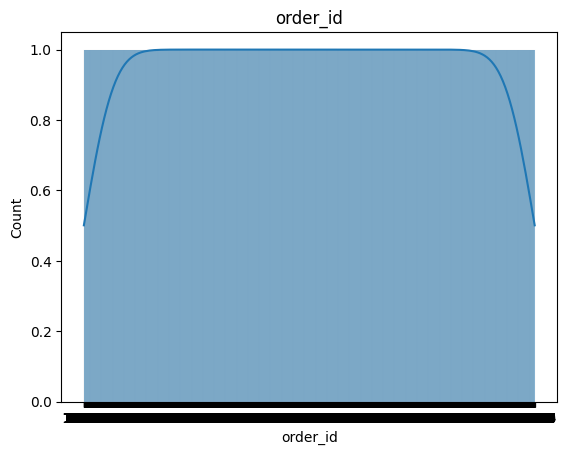

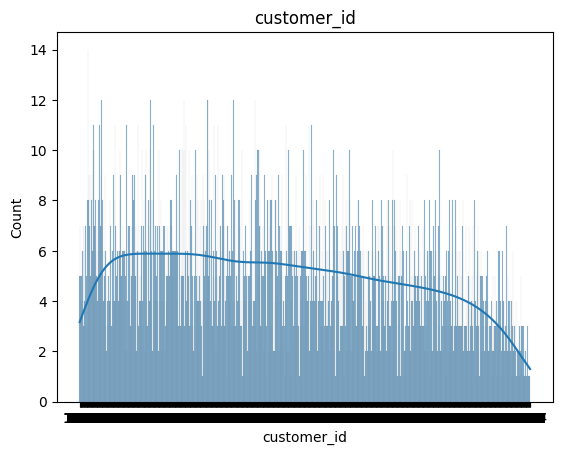

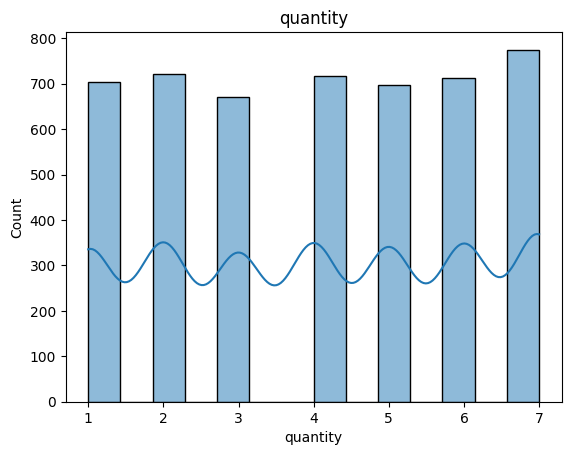

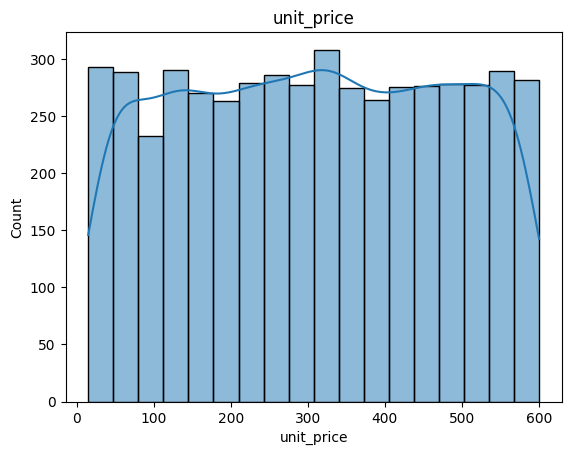

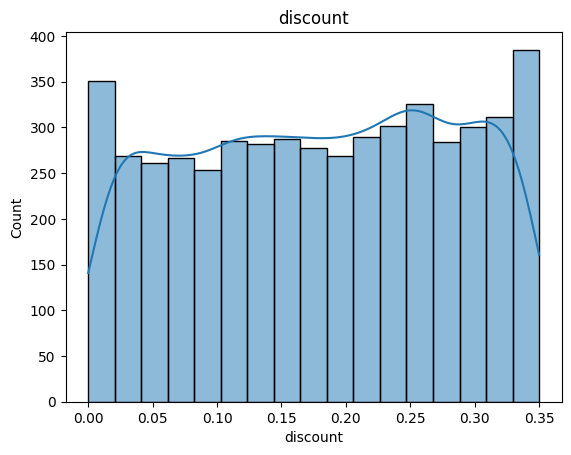

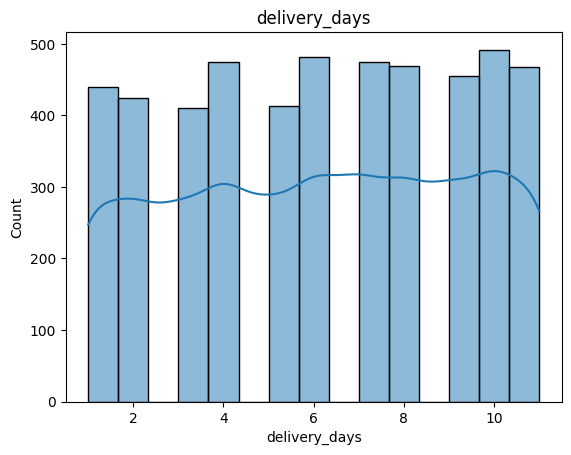

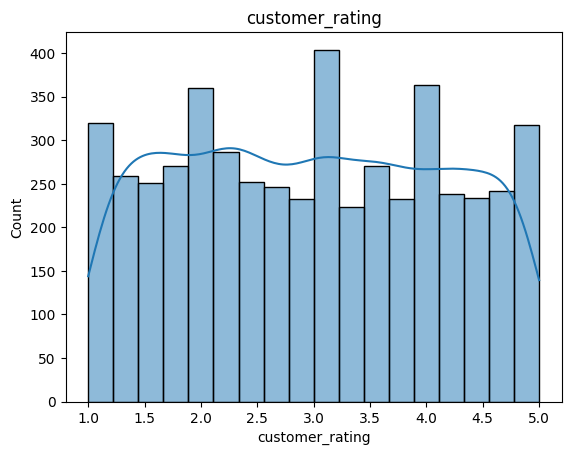

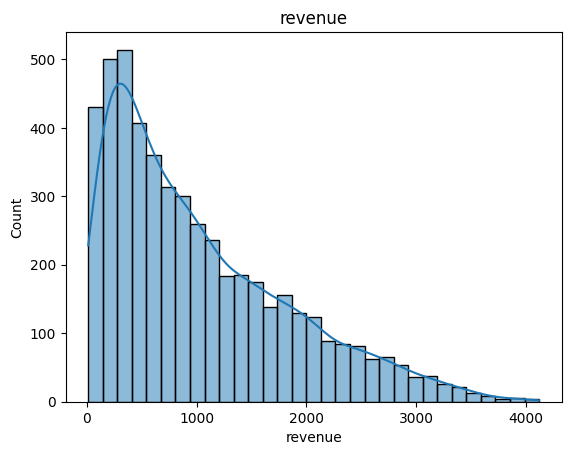

In [21]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### Category vs Revenue

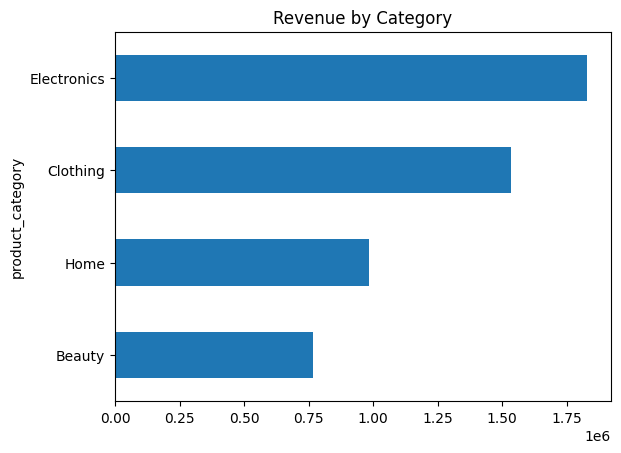

In [22]:
cat_agg = df.groupby('product_category')['revenue'].sum().sort_values()

cat_agg.plot(kind='barh', title="Revenue by Category")
plt.show()

### Time Series Trend

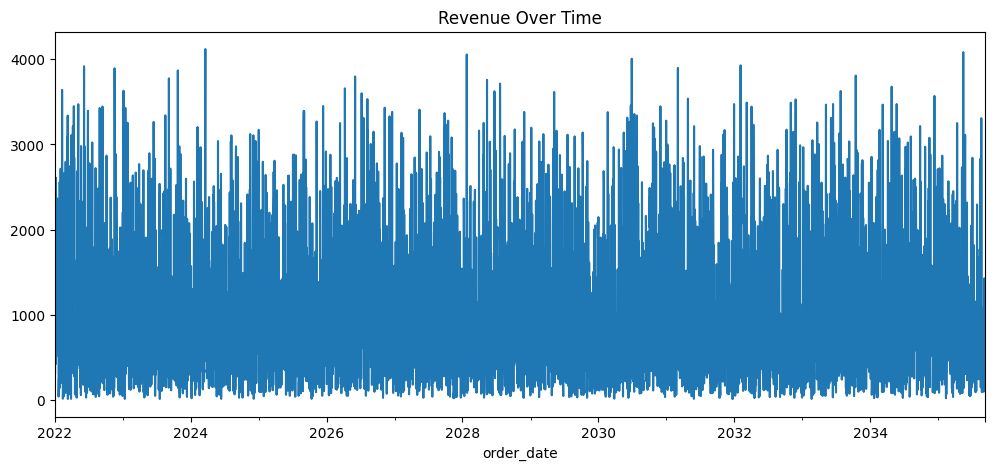

In [23]:
ts = df.groupby('order_date')['revenue'].sum()

ts.plot(figsize=(12,5), title="Revenue Over Time")
plt.show()

### Correlation Analysis

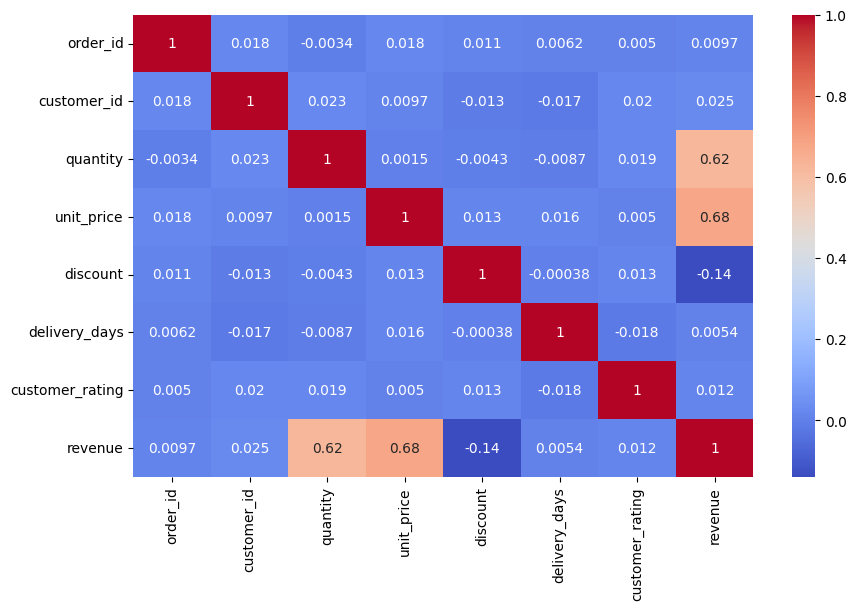

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [25]:
df_final = df.copy()
df_final = df_final.drop(columns=["_id"])

# print(df_final.shape)
df_final.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,dayofweek,expected_revenue,revenue_diff
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,Saturday,1883.1960,0.0040
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,Sunday,304.1038,-0.0038
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,Cod,6,2.5,644.35,2022,1,Monday,644.3496,0.0004
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,Tuesday,2569.9030,-0.0030
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,Wednesday,468.5645,-0.0045


## Data Transformations

### Transaction Data → Customer-Level Dataset

In [26]:
# Ensure date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Reference date (important for recency)
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

RFM Features

In [27]:
customer_df = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',                                     # Frequency
    'revenue': 'sum'                                         # Monetary
}).rename(columns={
    'order_date': 'recency',
    'order_id': 'frequency',
    'revenue': 'monetary'
}).reset_index()

Additional Behavioral Features

In [28]:
extra_features = df.groupby('customer_id').agg({
    'quantity': 'sum',
    'discount': 'mean',
    'delivery_days': 'mean',
    'customer_rating': 'mean',
    'product_category': pd.Series.nunique,
    'payment_method': pd.Series.nunique
}).rename(columns={
    'quantity': 'total_quantity',
    'discount': 'avg_discount',
    'delivery_days': 'avg_delivery_days',
    'customer_rating': 'avg_rating',
    'product_category': 'unique_categories',
    'payment_method': 'unique_payment_methods'
}).reset_index()

customer_df = customer_df.merge(extra_features, on='customer_id', how='left')

Purchase Consistency

In [29]:
purchase_gap = df.sort_values(['customer_id', 'order_date'])

purchase_gap['prev_date'] = purchase_gap.groupby('customer_id')['order_date'].shift(1)
purchase_gap['gap'] = (purchase_gap['order_date'] - purchase_gap['prev_date']).dt.days

gap_features = purchase_gap.groupby('customer_id')['gap'].mean().reset_index()
gap_features.rename(columns={'gap': 'avg_purchase_gap'}, inplace=True)

customer_df = customer_df.merge(gap_features, on='customer_id', how='left')

Data Validation Before Modeling

In [30]:
customer_df.describe()

# Missing values
print(customer_df.isnull().sum())

# Fill gaps (important)
customer_df.fillna({
    'avg_purchase_gap': customer_df['avg_purchase_gap'].median()
}, inplace=True)

customer_id                0
recency                    0
frequency                  0
monetary                   0
total_quantity             0
avg_discount               0
avg_delivery_days          0
avg_rating                 0
unique_categories          0
unique_payment_methods     0
avg_purchase_gap          39
dtype: int64


,customer_id,recency,frequency,monetary,total_quantity,avg_discount,avg_delivery_days,avg_rating,unique_categories,unique_payment_methods,avg_purchase_gap
0,1000,66,9,6905.58,27,0.134444,5.444444,2.633333,3,3,504.625000
1,1001,2018,6,3959.74,18,0.240000,6.333333,2.666667,3,3,578.400000
2,1002,2084,4,1579.67,15,0.215000,7.500000,3.800000,3,2,562.000000
3,1003,3184,2,2304.44,9,0.185000,5.000000,3.000000,2,1,490.000000
4,1004,3573,5,6073.85,16,0.120000,6.800000,2.320000,2,2,312.000000
...,...,...,...,...,...,...,...,...,...,...,...
984,1995,216,4,4082.06,20,0.150000,5.250000,2.650000,3,3,1560.000000
985,1996,1580,7,7053.98,32,0.184286,5.000000,2.328571,3,3,521.833333
986,1997,373,6,6466.30,31,0.236667,4.333333,3.483333,3,3,658.800000
987,1998,202,5,7213.69,31,0.228000,5.200000,3.360000,3,3,1041.750000


### Feature Transformation

Handle Skewness

In [31]:
import numpy as np

skewed_cols = ['monetary', 'frequency', 'total_quantity']

for col in skewed_cols:
    customer_df[col] = np.log1p(customer_df[col])

Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

features = customer_df.drop(columns=['customer_id'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [33]:
X = customer_df.drop(columns=['customer_id'])

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

Train-Test Split (for stability, not prediction)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

Scaling (fit ONLY on train)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Automatic Optimal Clusters Selection

Silhouette Score (primary) & Davies–Bouldin (secondary check)

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    
    sil_score = silhouette_score(X_train_scaled, labels)
    db_score = davies_bouldin_score(X_train_scaled, labels)
    
    results.append((k, sil_score, db_score))

# Convert to DataFrame
import pandas as pd
results_df = pd.DataFrame(results, columns=['k', 'silhouette', 'davies_bouldin'])

print(results_df)

    k  silhouette  davies_bouldin
0   2    0.296628        1.524969
1   3    0.167511        1.943368
2   4    0.165854        1.812807
3   5    0.138687        1.989759
4   6    0.128228        1.933504
5   7    0.113060        1.994052
6   8    0.117072        1.928656
7   9    0.111144        1.905872
8  10    0.117047        1.855111


In [37]:
# Best k based on highest silhouette score
best_k = results_df.sort_values('silhouette', ascending=False).iloc[0]['k']
best_k = int(best_k)

print("Optimal K:", best_k)

Optimal K: 2


### Train Final KMeans Model

In [38]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

In [39]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['cluster'] = train_clusters
X_test['cluster'] = test_clusters

Validate Cluster Stability

In [40]:
from sklearn.metrics import silhouette_score

train_sil = silhouette_score(X_train_scaled, train_clusters)
test_sil = silhouette_score(X_test_scaled, test_clusters)

print("Train Silhouette:", train_sil)
print("Test Silhouette:", test_sil)

Train Silhouette: 0.2966281395102486
Test Silhouette: 0.3101925113837284


Adjusted Rand Index (ARI) : Measures similarity between two clusterings When we do different random splits in data

Range: ~1 → identical clustering
~0 → random

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import numpy as np

n_runs = 10
ari_scores = []

for i in range(n_runs):
    
    # Split
    X_train, X_test = train_test_split(X, test_size=0.3, random_state=i)
    
    # Scale (fit only on train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    
    # Predict on test
    test_labels = kmeans.predict(X_test_scaled)
    
    # Refit on test (independent clustering)
    kmeans_test = KMeans(n_clusters=2, random_state=42, n_init=10)
    test_labels_ref = kmeans_test.fit_predict(X_test_scaled)
    
    # Compare clusterings
    ari = adjusted_rand_score(test_labels_ref, test_labels)
    ari_scores.append(ari)

print("ARI scores:", ari_scores)
print("Mean ARI:", np.mean(ari_scores))

ARI scores: [0.8285064764213518, 0.9593324510441668, 0.7302309566051057, 0.9056827364019515, 0.9725172160820008, 0.8919541482810811, 0.880635454889218, 0.8528759139273773, 0.8641194724515832, 0.9330425752072122]
Mean ARI: 0.8818897401311048


Final Dataset with Clusters

In [41]:
customer_df_final = customer_df.copy()

# Scale full data with trained scaler
X_full_scaled = scaler.transform(customer_df.drop(columns=['customer_id']))

customer_df_final['cluster'] = kmeans.predict(X_full_scaled)

In [42]:
cluster_summary = customer_df_final.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

             recency  frequency  monetary  total_quantity  avg_discount  \
cluster                                                                   
0         744.020802   1.938968  8.691359        3.218099      0.180423   
1        1526.655063   1.259884  7.575547        2.297998      0.179258   

         avg_delivery_days  avg_rating  unique_categories  \
cluster                                                     
0                 6.121666    2.973671           3.126300   
1                 6.116192    2.954868           1.933544   

         unique_payment_methods  avg_purchase_gap  
cluster                                            
0                      2.619614        717.010681  
1                      1.765823       1273.134705  


### Final Segment Definition

-------

Cluster 0 → "Active High-Value Customers"

Characteristics:
- More recent purchases
- Higher spend
- Higher frequency
- Multi-category buyers
- Lower purchase gaps

These customers are :
- Core revenue drivers
- Retention-critical users

--------

Cluster 1 → "Dormant / Low-Engagement Customers"

Characteristics:
- Very high recency (inactive)
- Low spend
- Low frequency
- Limited exploration
- Large purchase gaps

These customers are :
- Churned or near-churn users
------

### Business Actions 
----
🟢 Cluster 0 (High Value)
- Loyalty programs
- Early access / premium features
- Cross-sell (since they explore categories)
----
🔴 Cluster 1 (Dormant)
- Reactivation campaigns
- Discounts / offers
- Email / push targeting
-----

Cluster Size Distribution

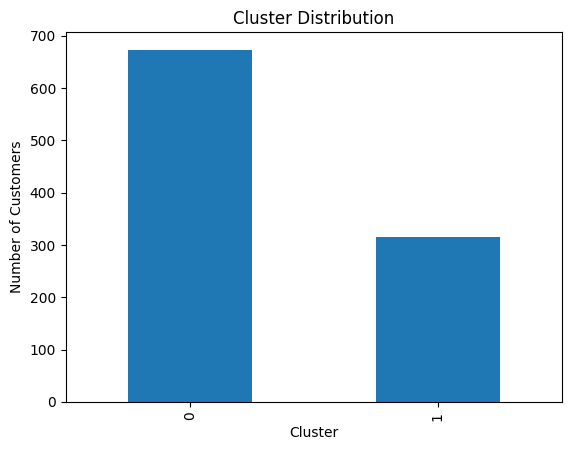

In [43]:
customer_df_final['cluster'].value_counts().plot(kind='bar')

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

Cluster Profile Heatmap

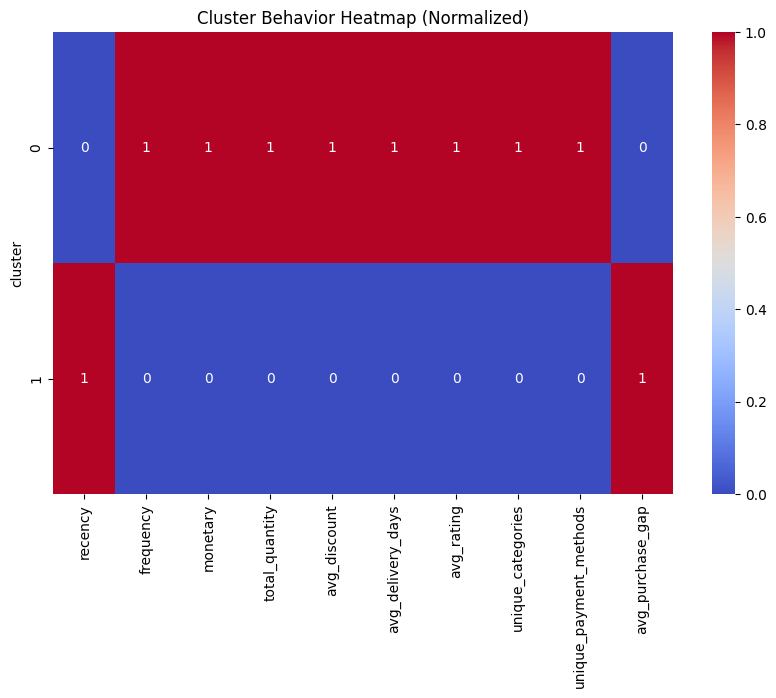

In [44]:
import seaborn as sns

# Normalize for comparison
cluster_profile = customer_df_final.groupby('cluster').mean(numeric_only=True)

normalized = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(10,6))
sns.heatmap(normalized, annot=True, cmap='coolwarm')

plt.title("Cluster Behavior Heatmap (Normalized)")
plt.show()

PCA Visualization

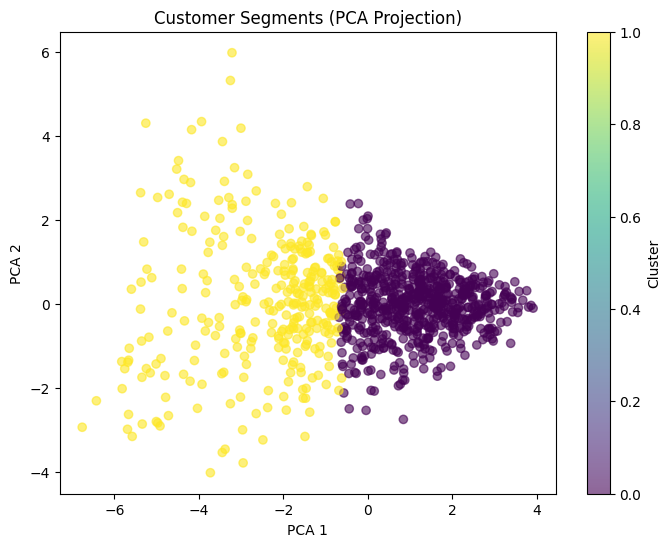

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], 
            c=customer_df_final['cluster'], cmap='viridis', alpha=0.6)

plt.title("Customer Segments (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label='Cluster')
plt.show()

Recency vs Monetary

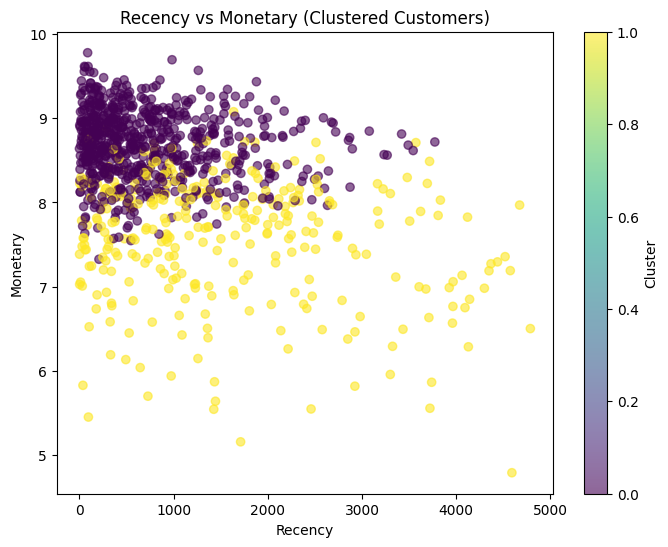

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_df_final['recency'],
    customer_df_final['monetary'],
    c=customer_df_final['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Recency vs Monetary (Clustered Customers)")
plt.colorbar(label='Cluster')
plt.show()

Frequency vs Monetary

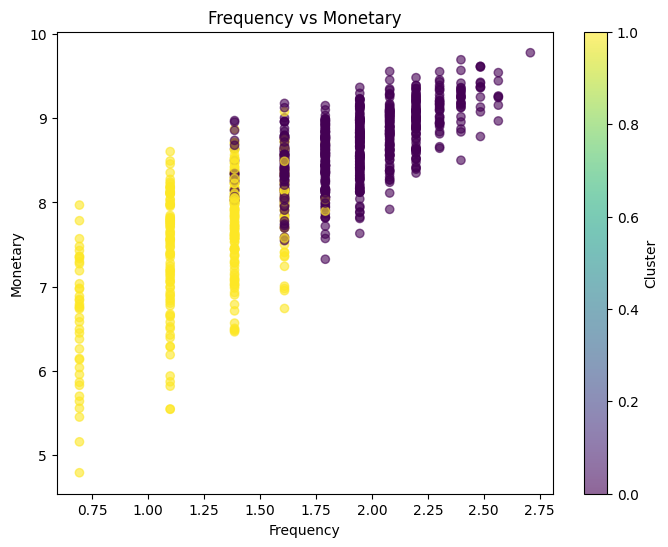

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_df_final['frequency'],
    customer_df_final['monetary'],
    c=customer_df_final['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Monetary")
plt.colorbar(label='Cluster')
plt.show()

Recency vs Frequency

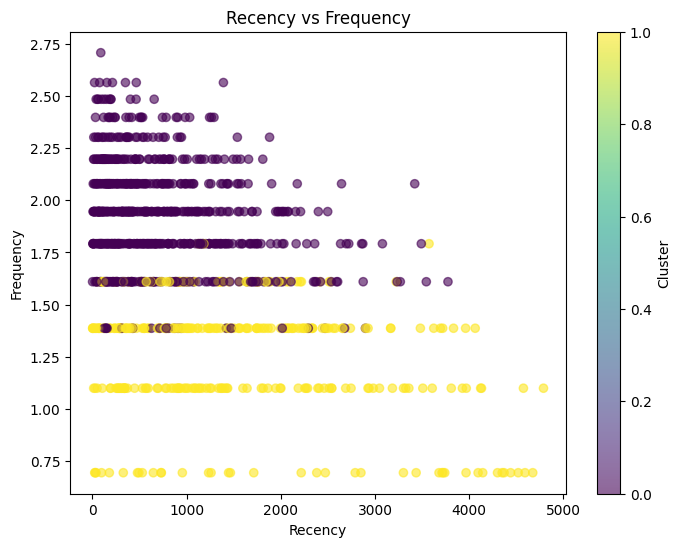

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_df_final['recency'],
    customer_df_final['frequency'],
    c=customer_df_final['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Recency vs Frequency")
plt.colorbar(label='Cluster')
plt.show()

3D RFM Plot

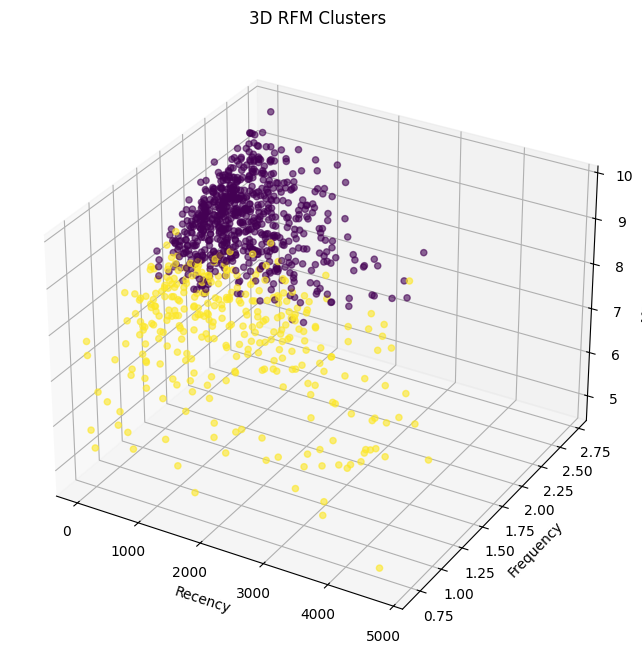

In [49]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    customer_df_final['recency'],
    customer_df_final['frequency'],
    customer_df_final['monetary'],
    c=customer_df_final['cluster'],
    cmap='viridis',
    alpha=0.6
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title("3D RFM Clusters")
plt.show()